
# Helmet Detection using YOLOv8

## Project Overview

This project fine-tunes YOLOv8 on the Hard Hat Detection dataset. The workflow includes:

- Converting Pascal VOC XML annotations to YOLO format
- Preparing the dataset
- Fine-tuning a pretrained YOLOv8 model
- Evaluating performance
- Running inference on unseen images



In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download andrewmvd/hard-hat-detection

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection
License(s): CC0-1.0
100% 1.22G/1.22G [00:13<00:00, 97.7MB/s]



In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/hard-hat-detection.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.8 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
model = YOLO('yolov8n.pt')

In [7]:
#Yolo expects data in COCO format that the annotation must be in .txt format
#Parsing and converting from XML to .txt
import xml.etree.ElementTree as ET

In [8]:
import os
annotation_folder = "/content/annotations"

#label folder storing the annotations in .txt format
label_folder = "/content/labels"
os.makedirs(label_folder, exist_ok=True)

#accessing the annotation folder
xml_file=os.listdir("/content/annotations")

#classes
class_id = {"helmet":0,"head":1,"person":2}

for file in xml_file:
  #XML parsing
  xml_path = os.path.join(annotation_folder,file)
  tree = ET.parse(xml_path)
  root = tree.getroot()

  #accesing each element in the xml file
  filename = root.find("filename").text
  txt_name = os.path.splitext(filename)[0] + ".txt"
  txt_path = os.path.join(label_folder,txt_name)

  size = root.find("size")   #image size element
  image_height = int(size.find("height").text)  #image height value
  image_width = int(size.find("width").text)    #image width value

  #getting the list of each object element
  objects = root.findall("object")

  #opening the corresponding txt file to perfom write operation
  with open(txt_path,"w") as f:

    for obj in objects:
      c_id = class_id[obj.find("name").text]   #class id

      bndbox = obj.find("bndbox")    #bounding box element

      xmin = int(bndbox.find("xmin").text)      #xmin value
      ymin = int(bndbox.find("ymin").text)      #ymin value
      xmax = int(bndbox.find("xmax").text)      #xmax value
      ymax = int(bndbox.find("ymax").text)      #ymax value


      #Calcuting the x_center,y_center,height,width of the bounding box
      x_center = (xmin+xmax)/2
      y_center = (ymin+ymax)/2
      height = ymax-ymin
      width = xmax-xmin

      #Normalize the bounding box data
      x_center = round(x_center / image_width,6)
      y_center = round(y_center / image_height,6)
      height = round(height / image_height,6)
      width = round(width / image_width,6)

      #Writing the c_id,x_center,y_center,width,height values for each object
      f.write(f"{c_id} {x_center} {y_center} {width} {height}\n")

In [9]:
#Creating train and validation folders
base = "/content/helmet_dataset"
folders = [
    'images/train',
    'images/val',
    'labels/train',
    'labels/val'
]

for folder in folders:
  os.makedirs(os.path.join(base,folder), exist_ok=True)

In [10]:
image_files = os.listdir("/content/images")
image_files

['hard_hat_workers3638.png',
 'hard_hat_workers1436.png',
 'hard_hat_workers1170.png',
 'hard_hat_workers3503.png',
 'hard_hat_workers2936.png',
 'hard_hat_workers4745.png',
 'hard_hat_workers2704.png',
 'hard_hat_workers241.png',
 'hard_hat_workers3523.png',
 'hard_hat_workers1952.png',
 'hard_hat_workers296.png',
 'hard_hat_workers1089.png',
 'hard_hat_workers1069.png',
 'hard_hat_workers2151.png',
 'hard_hat_workers1864.png',
 'hard_hat_workers1524.png',
 'hard_hat_workers2185.png',
 'hard_hat_workers2436.png',
 'hard_hat_workers3232.png',
 'hard_hat_workers3860.png',
 'hard_hat_workers4390.png',
 'hard_hat_workers1747.png',
 'hard_hat_workers870.png',
 'hard_hat_workers732.png',
 'hard_hat_workers240.png',
 'hard_hat_workers3379.png',
 'hard_hat_workers2699.png',
 'hard_hat_workers4267.png',
 'hard_hat_workers60.png',
 'hard_hat_workers1337.png',
 'hard_hat_workers552.png',
 'hard_hat_workers3833.png',
 'hard_hat_workers1610.png',
 'hard_hat_workers4913.png',
 'hard_hat_workers2529

In [11]:
import random
random.seed(42)
random.shuffle(image_files)

#Spliting the dataset as 80% for training and 20% for validation
split = int(0.8*len(image_files))
train_images = image_files[:split]
val_images = image_files[split:]

In [12]:
import shutil
#using shutil to perform high level file operations

for image in train_images:
  label_name = os.path.splitext(image)[0]+'.txt'
  image_src = os.path.join('/content/images',image)
  image_dst = os.path.join('/content/helmet_dataset/images/train',image)
  label_src = os.path.join('/content/labels',label_name)
  label_dst = os.path.join('/content/helmet_dataset/labels/train',label_name)

  shutil.copy(image_src,image_dst)
  shutil.copy(label_src,label_dst)


for image in val_images:
  label_name = os.path.splitext(image)[0]+'.txt'
  image_src = os.path.join('/content/images',image)
  image_dst = os.path.join('/content/helmet_dataset/images/val',image)
  label_src = os.path.join('/content/labels',label_name)
  label_dst = os.path.join('/content/helmet_dataset/labels/val',label_name)

  shutil.copy(image_src,image_dst)
  shutil.copy(label_src,label_dst)

In [16]:
#Creating the data.yaml config file to provide the data paths ,number of class,names
data_yaml = """
train: /content/helmet_dataset/images/train
val: /content/helmet_dataset/images/val

nc: 3

names:
  0: helmet
  1: head
  2: person
"""

with open("/content/data.yaml","w") as f:
  f.write(data_yaml)

In [17]:
#traing the YOLOV8s model for helmet detection for 50 epochs
results = model.train(
    data = '/content/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, opt

In [18]:
#Testing our model best.pt
test_model = YOLO("/content/runs/detect/train-2/weights/best.pt")

In [19]:
#Using a new unseen test image
test_results = test_model.predict(
    source="test_image.jpg",
    conf=0.25,
    save=True
)


image 1/1 /content/test_image.jpg: 288x640 4 helmets, 41.6ms
Speed: 1.9ms preprocess, 41.6ms inference, 2.4ms postprocess per image at shape (1, 3, 288, 640)
Results saved to /content/runs/detect/predict


## Final Performance

Precision: 94.6%

Recall: 58.7%

mAP@50: 63.1%

mAP@50-95: 41.6%

(np.float64(-0.5), np.float64(785.5), np.float64(349.5), np.float64(-0.5))

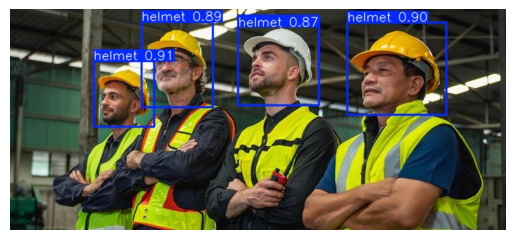

In [20]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open('/content/runs/detect/predict/test_image.jpg')
plt.imshow(img)
plt.axis("off")